In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("heart_disease.xlsx")

In [3]:
df.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [4]:
df.shape

(303, 14)

(array([ 1., 10., 33., 38., 37., 60., 64., 43., 14.,  3.]),
 array([29. , 33.8, 38.6, 43.4, 48.2, 53. , 57.8, 62.6, 67.4, 72.2, 77. ]),
 <BarContainer object of 10 artists>)

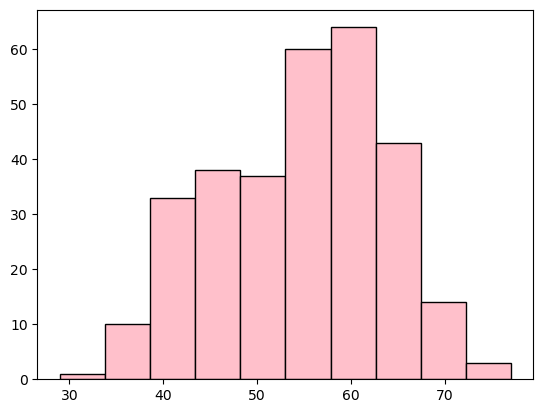

In [5]:
plt.hist(df['age'],bins = 10, alpha=1 , color= 'pink', edgecolor='black')

In [6]:
print(df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
0        3  0.0   6.0    0  
1        2  3.0   3.0    2  


In [7]:
mean_values = df.mean(numeric_only=True)
median_values = df.median(numeric_only=True)
mode_values = df.mode(numeric_only=True).iloc[0]  # First mode in case of multiple modes
std_values = df.std(numeric_only=True)

#to combine kolo to a single dataframe
summary_stats = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Mode': mode_values,
    'Std (Standard Deviation)': std_values
})

summary_stats

,Mean,Median,Mode,Std (Standard Deviation)
age,54.438944,56.0,58.0,9.038662
sex,0.679868,1.0,1.0,0.467299
cp,3.158416,3.0,4.0,0.960126
trestbps,131.689769,130.0,120.0,17.599748
chol,246.693069,241.0,197.0,51.776918
fbs,0.148515,0.0,0.0,0.356198
restecg,0.990099,1.0,0.0,0.994971
thalach,149.607261,153.0,162.0,22.875003
exang,0.326733,0.0,0.0,0.469794
oldpeak,1.039604,0.8,0.0,1.161075


In [8]:
Q1 = df[['chol', 'oldpeak', 'thalach']].quantile(0.25)
Q3 = df[['chol', 'oldpeak', 'thalach']].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

chol       64.0
oldpeak     1.6
thalach    32.5
dtype: float64


In [9]:
selected_cols = ['chol', 'oldpeak', 'thalach']

Q1 = df[selected_cols].quantile(0.25)
Q3 = df[selected_cols].quantile(0.75)
IQR = Q3 - Q1

# Filter outliers based only on selected columns
outliers = df[
    ((df[selected_cols] < (Q1 - 1.5 * IQR)) | 
     (df[selected_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("\nPotential outliers in the dataset based on boxplot analysis:")
print(outliers)


Potential outliers in the dataset based on boxplot analysis:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
48    65    0   3       140   417    1        2      157      0      0.8   
91    62    0   4       160   164    0        2      145      0      6.2   
121   63    0   4       150   407    0        2      154      0      4.0   
123   55    1   4       140   217    0        0      111      1      5.6   
152   67    0   3       115   564    0        2      160      0      1.6   
173   62    0   4       140   394    0        2      157      0      1.2   
181   56    0   4       134   409    0        2      150      1      1.9   
183   59    1   1       178   270    0        2      145      0      4.2   
191   51    1   4       140   298    0        0      122      1      4.2   
245   67    1   4       120   237    0        0       71      0      1.0   
285   58    1   4       114   318    0        1      140      0      4.4   

     slope   ca  thal  nu

In [10]:
print(df.sort_values('num', ascending= False))

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
24    60    1   4       130   206    0        2      132      1      2.4   
174   64    1   4       145   212    0        2      132      0      2.0   
40    65    0   4       150   225    0        2      114      0      1.0   
146   57    1   4       165   289    1        2      124      0      1.0   
264   61    1   4       138   166    0        2      125      1      3.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
133   51    1   4       140   261    0        2      186      1      0.0   
134   43    0   3       122   213    0        0      165      0      0.2   
135   55    0   2       135   250    0        2      161      0      1.4   
139   51    1   3       125   245    1        2      166      0      2.4   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
24       2  2.0   7.0    4  
174      2  2.0   6.0    4  


In [11]:
age_mode= df['age'].mode().tolist()
print(f"Age mode: {age_mode}")

Age mode: [58]


In [12]:
df.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,False,False,False,False
300,False,False,False,False,False,False,False,False,False,False,False,False,False,False
301,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [14]:
df.isnull().sum().sum()

6

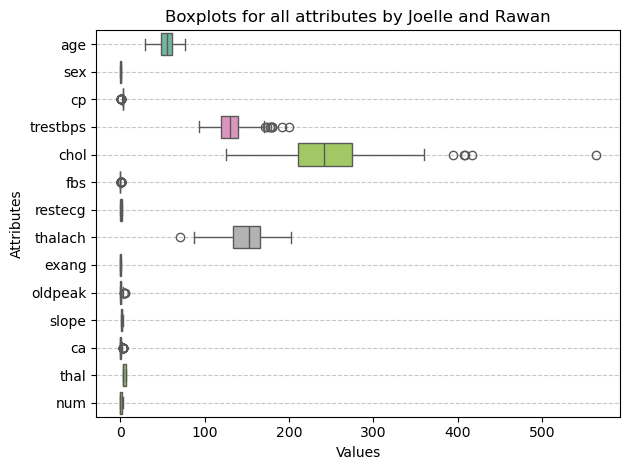

In [15]:
sns.boxplot(data=df,orient="h",palette="Set2")
plt.title('Boxplots for all attributes by Joelle and Rawan')
plt.xlabel("Values")
plt.ylabel("Attributes")
plt.tight_layout()
plt.grid(axis = 'y', linestyle = '--', alpha= 0.7)
plt.show()

In [16]:
#handling missing values using "Imputation Strategy"
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

In [17]:
df.isnull().sum().sum()

0

In [18]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [19]:
plt.style.use('ggplot')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier

In [20]:
scaler = MinMaxScaler()
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
df[[col+ '_norm' for col in numeric_cols]]= scaler.fit_transform(df[numeric_cols])

In [21]:
df[[col+ '_norm' for col in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']]].head()

,age_norm,trestbps_norm,chol_norm,thalach_norm,oldpeak_norm,ca_norm
0,0.708333,0.481132,0.244292,0.603053,0.370968,0.000000
1,0.791667,0.622642,0.365297,0.282443,0.241935,1.000000
2,0.791667,0.245283,0.235160,0.442748,0.419355,0.666667
3,0.166667,0.339623,0.283105,0.885496,0.564516,0.000000
4,0.250000,0.339623,0.178082,0.770992,0.225806,0.000000


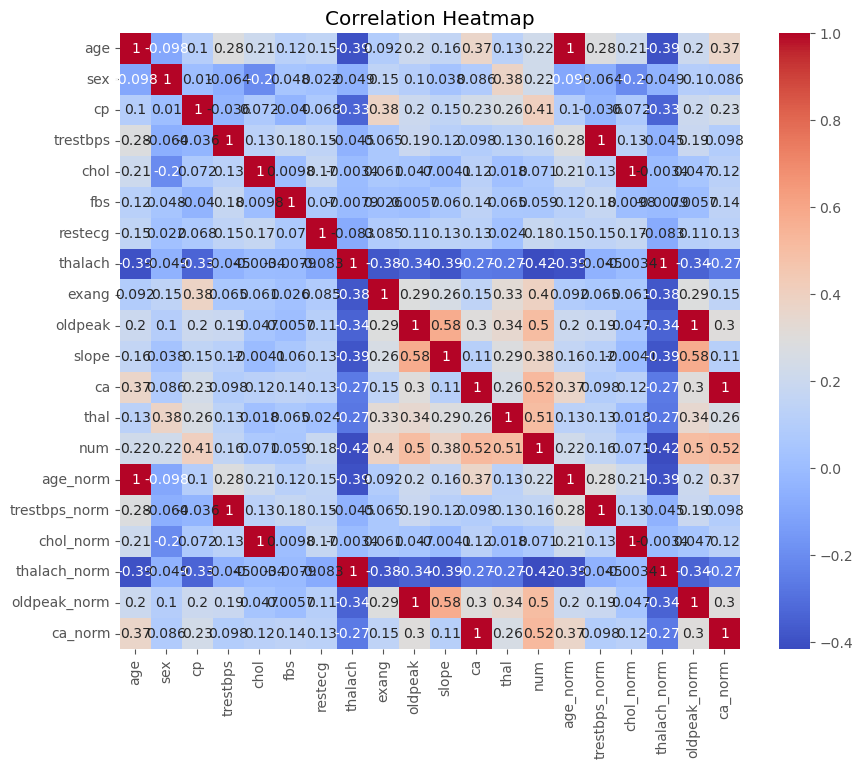

In [22]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

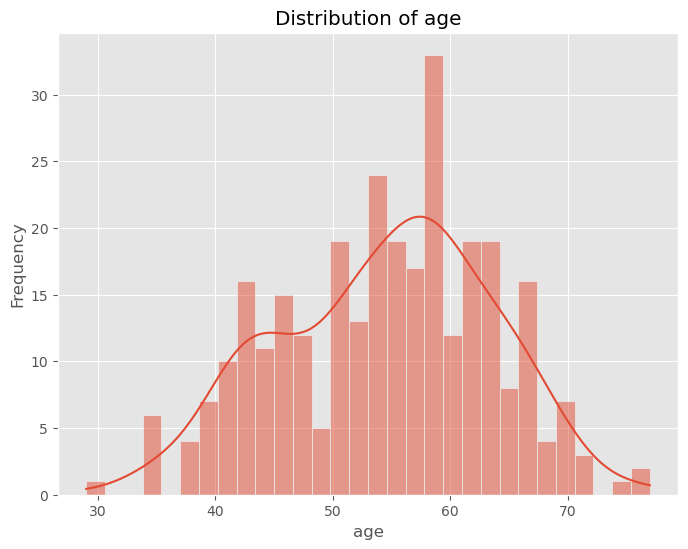

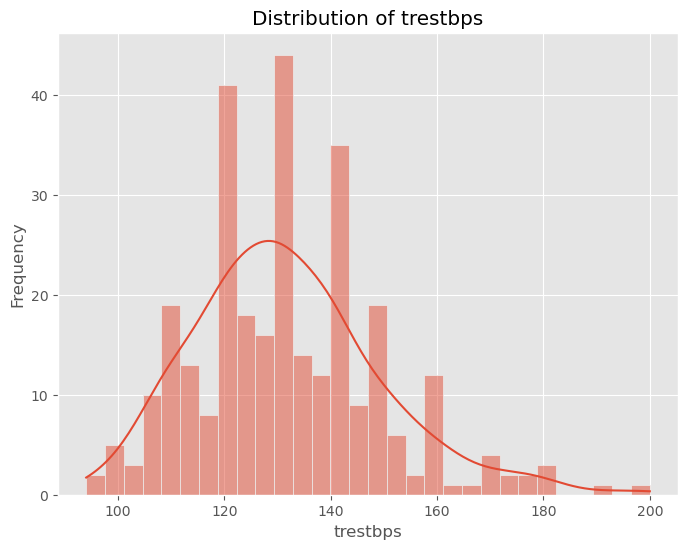

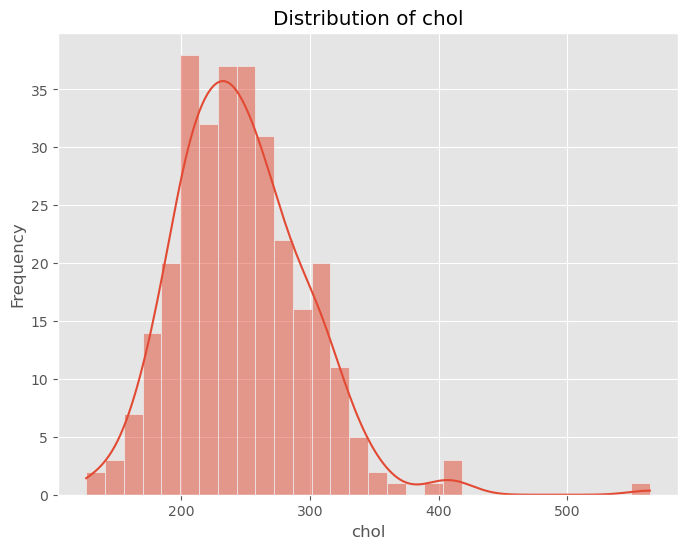

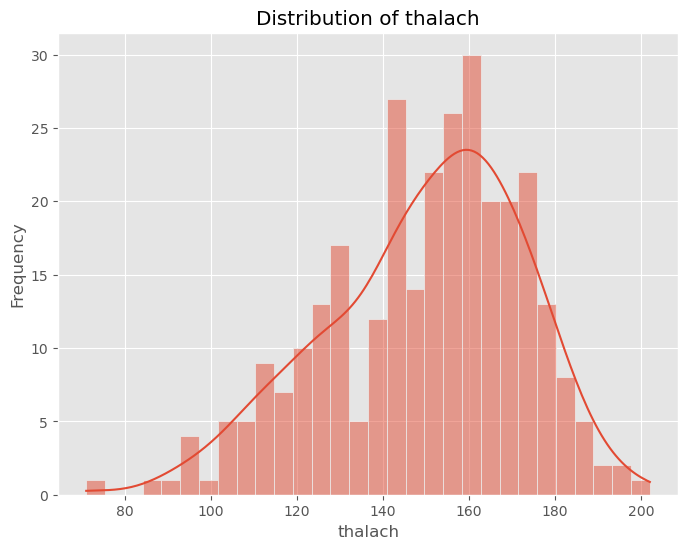

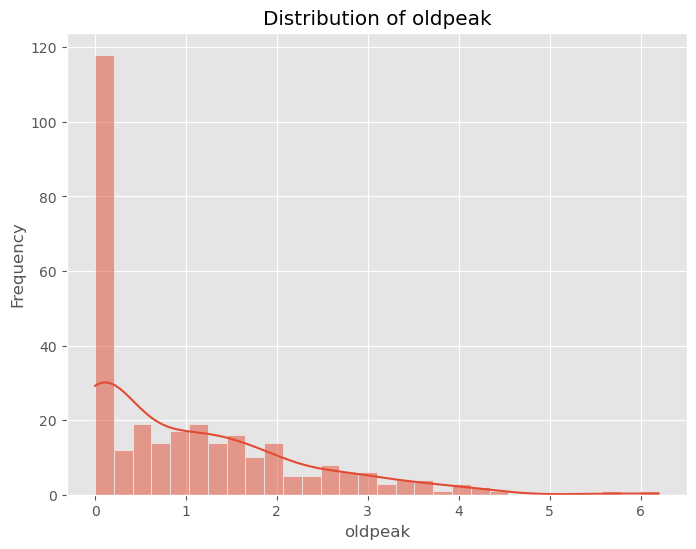

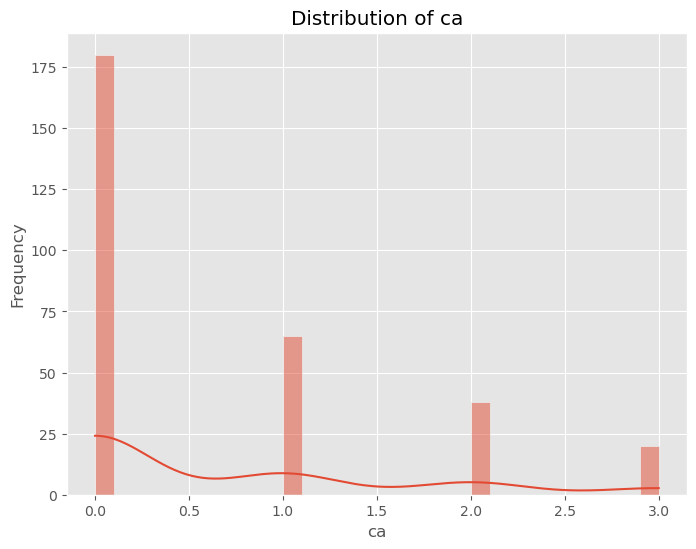

In [23]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
for feature in features:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [25]:
X = df[['trestbps','chol','thalach']]
y= df['num'].apply(lambda x:1 if x > 0 else 0) #convert target to binary 0(no disease) 1(disease)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training Accuracy: 0.71
Test Accuracy: 0.70
[[22  7]
 [11 21]]
              precision    recall  f1-score   support

           0       0.67      0.76      0.71        29
           1       0.75      0.66      0.70        32

    accuracy                           0.70        61
   macro avg       0.71      0.71      0.70        61
weighted avg       0.71      0.70      0.70        61



In [26]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[24  5]
 [13 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.83      0.73        29
           1       0.79      0.59      0.68        32

    accuracy                           0.70        61
   macro avg       0.72      0.71      0.70        61
weighted avg       0.72      0.70      0.70        61



In [28]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
from sklearn.svm import SVC

In [30]:
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", svm_model.score(X_test, y_test))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7213114754098361
SVM Confusion Matrix:
 [[21  8]
 [ 9 23]]
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.72      0.71        29
           1       0.74      0.72      0.73        32

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



In [31]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Accuracy:", tree_model.score(X_test, y_test))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.6885245901639344
Decision Tree Confusion Matrix:
 [[22  7]
 [12 20]]
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.76      0.70        29
           1       0.74      0.62      0.68        32

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.70      0.69      0.69        61



In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#logistic regression
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

#random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

#svm 
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Results
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nRandom Forest Feature Importances:")
print(pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False))

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.6721311475409836
Random Forest Accuracy: 0.6885245901639344
SVM Accuracy: 0.7213114754098361

Random Forest Feature Importances:
thalach     0.410076
chol        0.336519
trestbps    0.253405
dtype: float64

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.60      0.90      0.72        29
           1       0.83      0.47      0.60        32

    accuracy                           0.67        61
   macro avg       0.72      0.68      0.66        61
weighted avg       0.72      0.67      0.66        61


Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.64      0.79      0.71        29
           1       0.76      0.59      0.67        32

    accuracy                           0.69        61
   macro avg       0.70      0.69      0.69        61
weighted avg       0.70      0.69      0.69        61


Classification Repor

In [69]:
from sklearn.metrics import confusion_matrix

# Assuming you have your true labels and predicted labels
# y_true = actual labels (0 or 1)
# y_pred_log = predicted labels from Logistic Regression
# y_pred_rf = predicted labels from Random Forest
# y_pred_svm = predicted labels from SVM

def calculate_tn_tp_fn_fp(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"TN: {tn}, TP: {tp}, FN: {fn}, FP: {fp}")

# Example usage for each model:
print("Logistic Regression:")
calculate_tn_tp_fn_fp(y_test, y_pred_log)

print("\nRandom Forest:")
calculate_tn_tp_fn_fp(y_test, y_pred_rf)

print("\nSVM:")
calculate_tn_tp_fn_fp(y_test, y_pred_svm)


Logistic Regression:
TN: 26, TP: 15, FN: 17, FP: 3

Random Forest:
TN: 23, TP: 19, FN: 13, FP: 6

SVM:
TN: 21, TP: 23, FN: 9, FP: 8
